In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [1]:
import numpy as np

# Data points
X = np.array([1, 2, 3, 4, 5])
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1])

# Stack the design matrix with a column of ones (for the intercept) 
A = np.vstack([X, np.ones(len(X))]).T

print("X: ")
print(X)

print("Y: ")
print(Y)

print("A: ")
print(A)

X: 
[1 2 3 4 5]
Y: 
[1.2 2.8 3.6 4.5 5.1]
A: 
[[1. 1.]
 [2. 1.]
 [3. 1.]
 [4. 1.]
 [5. 1.]]


In [2]:
# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

Slope: 0.9500000000000001, Intercept: 0.5900000000000001


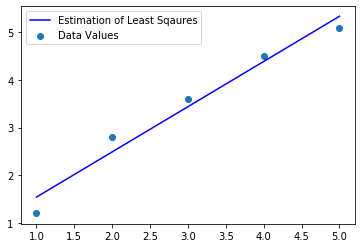

In [8]:
import matplotlib.pyplot as plt

yval = m*X + c
plt.scatter(X,Y, label="Data Values")
plt.plot(X,yval,'b', label= "Estimation of Least Sqaures")
plt.legend()
plt.show()


Slope: 0.7005387004750447, Intercept: 0.1895122189801328


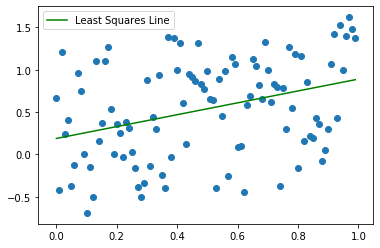

residuals:  [-0.4774395   0.61964476 -1.00640627 -0.02864342 -0.18453708  0.60227604
  0.35984506 -0.72280917 -0.50108252  0.24783922  0.94728773  0.41294569
  0.77774311 -0.8250991   0.13198508 -0.07748829 -0.80634144 -0.9654799
 -0.22660728  0.31572562 -0.02782207  0.08370181  0.36862535 -0.0330207
  0.03966624  0.33650441  0.53006339  0.76144095  0.88259708  0.72928352
 -0.48063407  0.54619734 -0.03329935  0.12004064 -0.50631594  0.67825616
  0.83313122 -0.93468069  0.47957582 -0.91010204 -0.52312072 -0.83489908
 -0.12761884  0.37046485 -0.44820408 -0.41108551 -0.35314972 -0.79486325
 -0.30596455 -0.23570209 -0.44934977 -0.10989924 -0.09089028  0.95389621
 -0.3176497   0.1225799  -0.40481361  0.84824334 -0.55420741 -0.46598043
  0.52299796  0.52066519  1.06662152  0.04668715 -0.05693124 -0.4797268
 -0.38970273 -0.16229991  0.01350628 -0.64980994 -0.32239906  0.06602901
 -0.1350007  -0.09985251  1.07405643 -0.06973673  0.42397864 -0.53991975
  0.19279794 -0.44074166  0.90474188 -0.40

In [16]:
import random
m = 0.5
b = 0.2
x = np.arange(0,1,0.01)
y = m*x+b
for i in range(len(x)): 
    err = random.uniform(-1,1)
    y[i]+=err
a = np.vstack([x, np.ones(len(x))]).T

# Solve using least squares
LSm, LSc = np.linalg.lstsq(a, y, rcond=None)[0]
print(f"Slope: {LSm}, Intercept: {LSc}")

plt.scatter(x,y)
plt.plot(x,LSm*x+LSc,'g', label = "Least Squares Line")
plt.legend()
plt.show()

resid = LSm*x+LSc-y
print("residuals: ", resid)

True line:   y = 4.885252091158936 x + 4.225151510976259
Estimated line: y = 4.885252091158936 x + 4.225151510976259

first couple residuals:
[ -8.48466345  -9.28742076 -11.13058279 -14.04071964 -15.12825111]
Largest residual:
X = 0.804 Y = -6.462811670286895 res = -15.12825111328753
Smallest residual:
X = 0.0 Y = -3.93020186777395 res = -8.484663447012778


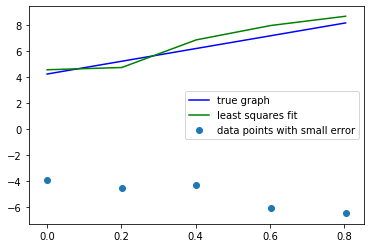

In [31]:
rng = np.random.default_rng()

#making my own numbers
X = np.arange(0, 1, .201)
m = rng.uniform(-10, 10) 
b = rng.uniform(-5, 5)

y = m * X + b


err = rng.uniform(-1, 1, size=len(X))  #errors
Y_err = m * X + b + err


A = np.vstack([X, np.ones(len(X))]).T
m_est, b_est = np.linalg.lstsq(A, Y, rcond=None)[0]
y_est = m_est*X + b_est

res = Y - Y_err


max_i = np.argmax(np.abs(res)) #calculating max residual
min_i = np.argmin(np.abs(res)) #calculating minimum residual

print("True line:   y =", m, "x +", b)
print("Estimated line: y =", m, "x +", b)
print()

print("first couple residuals:")
print(res[:10])

print("Largest residual:")
print("X =", X[max_i], "Y =", Y[max_i], "res =", res[max_i])

print("Smallest residual:")
print("X =", X[min_i], "Y =", Y[min_i], "res =", res[min_i])


plt.plot(X, y, 'b', label="true graph")
plt.scatter(X, Y, label="data points with small error")
plt.plot(X, Y_err, 'g',label="least squares fit")
plt.legend()
plt.show()